In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

sat_df = pd.read_csv("sat-by-state-1995.csv")

# Display dataset overview
print(f"Dataset shape: {sat_df.shape}")
sat_df.head()

Dataset shape: (50, 8)


,state,expend,ratio,salary,frac,verbal,math,sat
0,Alabama,4.405,17.2,31.144,8,491,538,1029
1,Alaska,8.963,17.6,47.951,47,445,489,934
2,Arizona,4.778,19.3,32.175,27,448,496,944
3,Arkansas,4.459,17.1,28.934,6,482,523,1005
4,California,4.992,24.0,41.078,45,417,485,902


In [3]:
state_abbrevs = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

sat_df['abbr'] = sat_df['state'].map(state_abbrevs)

# alias used in code later
sat_df['total'] = sat_df['sat']

In [4]:
# Create participation rate bins based on percentage of graduates taking SAT
sat_df['participation_group'] = pd.cut(
    sat_df['frac'], 
    bins=[0, 15, 50, 100], 
    labels=['Low', 'Medium', 'High']
)

# Display count per group
sat_df['participation_group'].value_counts()

participation_group
Low       21
High      18
Medium    11
Name: count, dtype: int64

In [5]:
# 1. Pooled Simple Linear Regression (Expenditure only)
# R style formula; intercept and dummy variables automatically included
model_pooled = smf.ols('sat ~ expend', data=sat_df).fit()
print(model_pooled.summary())


                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     8.128
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00641
Time:                        13:12:03   Log-Likelihood:                -282.29
No. Observations:                  50   AIC:                             568.6
Df Residuals:                      48   BIC:                             572.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1089.2937     44.390     24.539      0.0

In [6]:
# Prepare feature matrix X and target array y
X = sm.add_constant(sat_df[['expend']])
y = sat_df['total']

# Fit OLS model using matrices
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     8.128
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00641
Time:                        13:12:03   Log-Likelihood:                -282.29
No. Observations:                  50   AIC:                             568.6
Df Residuals:                      48   BIC:                             572.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1089.2937     44.390     24.539      0.0

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

# 2. Print R^2 and Intercept
print(f"R-squared: {model.score(X, y):.4f}")
print(f"Intercept: {model.intercept_:.4f}\n")

# 3. Print Coefficients mapped to feature names
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col:8s}: {coef:8.4f}")
    


R-squared: 0.1448
Intercept: 1089.2937

Coefficients:
  const   :   0.0000
  expend  : -20.8922


In [16]:
# Multiple Linear Regression
#  what would happen if you included +math+verbal in the model ?
model_controlled = smf.ols('sat ~ expend + salary + ratio + frac ', data=sat_df).fit()

print(model_controlled.summary())


                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.346e+29
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:13:59   Log-Likelihood:                 1370.7
No. Observations:                  50   AIC:                            -2727.
Df Residuals:                      43   BIC:                            -2714.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.411e-13   1.71e-12      0.200      0.8

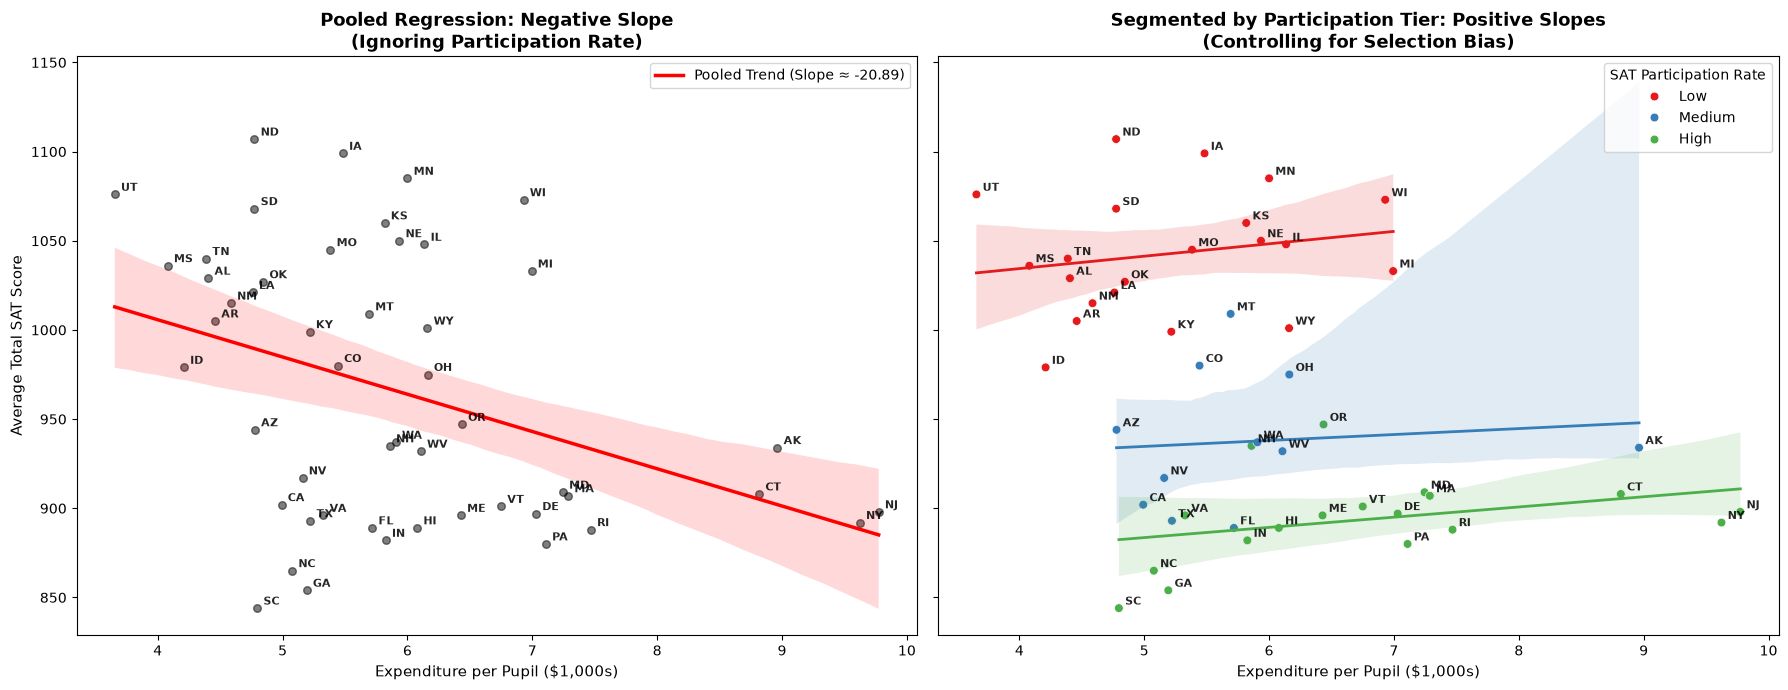

In [9]:
# 3. Side-by-Side Plotting with 2-Letter State Labels
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# ----------------------------------------------------
# Plot 1: Pooled Regression (Negative Slope)
# ----------------------------------------------------
sns.regplot(
    data=sat_df, 
    x='expend', 
    y='total', 
    ax=axes[0],
    color='black',
    line_kws={'color': 'red', 'linewidth': 2.5, 'label': 'Pooled Trend (Slope ≈ -20.89)'},
    scatter_kws={'alpha': 0.5, 's': 30}
)

# Add 2-letter labels for Plot 1
for _, row in sat_df.iterrows():
    axes[0].text(
        row['expend'] + 0.05, 
        row['total'] + 2, 
        row['abbr'], 
        fontsize=8, 
        alpha=0.85,
        fontweight='bold'
    )

axes[0].set_title("Pooled Regression: Negative Slope\n(Ignoring Participation Rate)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Expenditure per Pupil ($1,000s)", fontsize=11)
axes[0].set_ylabel("Average Total SAT Score", fontsize=11)
axes[0].legend(loc='upper right')

# ----------------------------------------------------
# Plot 2: Segmented Regression by Participation Tier
# ----------------------------------------------------
sns.scatterplot(
    data=sat_df, 
    x='expend', 
    y='total', 
    hue='participation_group', 
    palette='Set1',
    s=40,
    ax=axes[1]
)

# Fit individual regression lines per participation tier
palette = sns.color_palette('Set1', 3)
groups = ['Low', 'Medium', 'High']

for group, color in zip(groups, palette):
    sub_df = sat_df[sat_df['participation_group'] == group]
    sns.regplot(
        data=sub_df, 
        x='expend', 
        y='total', 
        ax=axes[1], 
        scatter=False, 
        color=color,
        line_kws={'linewidth': 2}
    )

# Add 2-letter labels for Plot 2
for _, row in sat_df.iterrows():
    axes[1].text(
        row['expend'] + 0.05, 
        row['total'] + 2, 
        row['abbr'], 
        fontsize=8, 
        alpha=0.85,
        fontweight='bold'
    )

axes[1].set_title("Segmented by Participation Tier: Positive Slopes\n(Controlling for Selection Bias)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Expenditure per Pupil ($1,000s)", fontsize=11)
axes[1].legend(title='SAT Participation Rate', loc='upper right')

plt.tight_layout()
plt.show()